# Assignment: Data Wrangling, Visualization, and Web Presentation
## Data Extraction
__Method description:__
I parsed the table using Beautiful Soup and stored links for movie pages. Then I entered every movie page to find data about directors, language, genre, duration, and country of origin.

In [292]:
import requests
import re
import time
import pandas as pd
from bs4 import BeautifulSoup
from pprint import pprint

import matplotlib.pyplot as plt

In [35]:
# Sending request
url = "https://en.wikipedia.org/wiki/List_of_highest-grossing_films"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

In [37]:
# Parsing a table from the page
soup = BeautifulSoup(response.text, "html.parser")

table = soup.find("table", {"class": "wikitable"})

In [437]:
# ensuring that data was accessed
table

<table class="wikitable sortable plainrowheaders sticky-header col4right col5center col6center">
<caption>Highest-grossing films<sup class="reference" id="cite_ref-12"><a href="#cite_note-12"><span class="cite-bracket">[</span>12<span class="cite-bracket">]</span></a></sup>
</caption>
<tbody><tr>
<th>Rank
</th>
<th>Peak
</th>
<th class="unsortable">Title
</th>
<th class="unsortable">Worldwide gross
</th>
<th>Year
</th>
<th class="unsortable"><abbr title="References">Ref</abbr>
</th></tr>
<tr>
<td>1
</td>
<td>1
</td>
<th scope="row"><i><a href="/wiki/Avatar_(2009_film)" title="Avatar (2009 film)">Avatar</a></i>
</th>
<td>$2,923,710,708
</td>
<td>2009
</td>
<td><sup class="reference" id="cite_ref-avatar_13-0"><a href="#cite_note-avatar-13"><span class="cite-bracket">[</span># 1<span class="cite-bracket">]</span></a></sup><sup class="reference" id="cite_ref-avatar_peak_14-0"><a href="#cite_note-avatar_peak-14"><span class="cite-bracket">[</span># 2<span class="cite-bracket">]</span></a></

In [439]:
# Extracting headers and rows of the table
movies = []

rows = table.find_all("tr")[1:]

for row in rows:
    tds = row.find_all("td")
    th = row.find("th")

    if not tds or not th:
        continue

    a_tag = th.find("a")
    title = a_tag.text.strip() if a_tag else th.text.strip()
    link = "https://en.wikipedia.org" + a_tag["href"] if a_tag else None

    gross = tds[2].text.strip()
    gross = gross.replace("$", "").replace(",", "")

    year = tds[3].text.strip()

    movies.append({
        "title": title,
        "year": int(year) if year.isdigit() else None,
        "gross": int(gross) if gross.isdigit() else None,
        "link": link
    })

In [441]:
# Checking what was saved
pprint(movies[:5])

[{'gross': 2923710708,
  'link': 'https://en.wikipedia.org/wiki/Avatar_(2009_film)',
  'title': 'Avatar',
  'year': 2009},
 {'gross': 2797501328,
  'link': 'https://en.wikipedia.org/wiki/Avengers:_Endgame',
  'title': 'Avengers: Endgame',
  'year': 2019},
 {'gross': 2334484620,
  'link': 'https://en.wikipedia.org/wiki/Avatar:_The_Way_of_Water',
  'title': 'Avatar: The Way of Water',
  'year': 2022},
 {'gross': None,
  'link': 'https://en.wikipedia.org/wiki/Titanic_(1997_film)',
  'title': 'Titanic',
  'year': 1997},
 {'gross': None,
  'link': 'https://en.wikipedia.org/wiki/Ne_Zha_2',
  'title': 'Ne Zha 2',
  'year': 2025}]


In [443]:
# Converting the list to the dataframe
df = pd.DataFrame(movies)

In [445]:
df.head()

,title,year,gross,link
0,Avatar,2009,2.923711e+09,https://en.wikipedia.org/wiki/Avatar_(2009_film)
1,Avengers: Endgame,2019,2.797501e+09,https://en.wikipedia.org/wiki/Avengers:_Endgame
2,Avatar: The Way of Water,2022,2.334485e+09,https://en.wikipedia.org/wiki/Avatar:_The_Way_...
3,Titanic,1997,NaN,https://en.wikipedia.org/wiki/Titanic_(1997_film)
4,Ne Zha 2,2025,NaN,https://en.wikipedia.org/wiki/Ne_Zha_2


In [447]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   title   50 non-null     object 
 1   year    50 non-null     int64  
 2   gross   44 non-null     float64
 3   link    50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB


### It seems that not all movies have gross extracted. After analyzing the table on Wikipedia, I found that gross for some movies is hidden behind another link. Need to insert these 6 grosses manually.

In [449]:
missing_gross = df[df['gross'].isna()]['title'].tolist()
print(missing_gross)

['Titanic', 'Ne Zha 2', 'Spider-Man: No Way Home', 'Frozen', 'The Fate of the Furious', 'The Dark Knight Rises']


In [451]:
df.loc[df['title'] == 'Titanic', 'gross'] = 2257906828
df.loc[df['title'] == 'Ne Zha 2', 'gross'] = 2215690000
df.loc[df['title'] == 'Spider-Man: No Way Home', 'gross'] = 1922598800
df.loc[df['title'] == 'Frozen', 'gross'] = 1290000000
df.loc[df['title'] == 'The Fate of the Furious', 'gross'] = 1238764765
df.loc[df['title'] == 'The Dark Knight Rises', 'gross'] = 1081169825

In [453]:
df[df['gross'].isna()]

,title,year,gross,link


### Having a link extracted for every movie, we can explore separate pages to gain more data

In [455]:
# Usually genre of the movie is mentioned in the first sentence in the main body. So, after analyzing the pattern, I can extract only info needed.
def extract_genres(soup):
    import re

    paragraphs = soup.find_all("p")
    text = None

    for p in paragraphs:
        t = p.get_text(" ", strip=True)
        if t:
            text = t
            break

    if not text:
        return None

    match = re.search(r"\b(19|20)\d{2}\b", text)
    if not match:
        return None

    after_year = text[match.end():]
    film_split = re.split(r"\bfilm\b", after_year, maxsplit=1)

    if not film_split:
        return None

    genre_part = film_split[0].lower()

    # removing country name in the beginning
    genre_part = re.sub(r"^(american|british|french|indian)\s+", "", genre_part)
    # splitting genres
    words = re.split(r"[ ,\-]+", genre_part)
    # removing excessive "and"
    genres = [w for w in words if w and w != "and"]

    return genres

In [457]:
def parse_movie_page(url):
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    infobox = soup.find("table", {"class": "infobox"})
    
    data = {
        "director": None,
        "country": None,
        "language": None,
        "running_time": None,
        'genres': None
    }

    if not infobox:
        return data

    for row in infobox.find_all("tr"):
        header = row.find("th")
        value = row.find("td")

        if not header or not value:
            continue

        key = header.get_text(strip=True)
        val = value.get_text(" ", strip=True)

        if key == "Directed by":
            directors = value.find_all("li")

            if directors:
                data["director"] = [d.get_text(strip=True) for d in directors]
            else:
                data["director"] = [value.get_text(strip=True)]
        elif key in ["Country", "Countries"]:
            countries = value.find_all("li")
            if countries:
                data["country"] = [c.get_text(strip=True) for c in countries]
            else:
                data["country"] = [value.get_text(strip=True)]
        elif key == "Language":
            data["language"] = val
        elif key == 'Running time':
            data['running_time'] = val

    data["genres"] = extract_genres(soup)

    return data

In [459]:
results = []

for url in df["link"]:
    info = parse_movie_page(url)
    results.append(info)
    time.sleep(1)

In [461]:
extra_info = pd.DataFrame(results)

df = pd.concat([df, extra_info], axis=1)

In [463]:
df.reset_index(inplace=True)

In [465]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         50 non-null     int64  
 1   title         50 non-null     object 
 2   year          50 non-null     int64  
 3   gross         50 non-null     float64
 4   link          50 non-null     object 
 5   director      50 non-null     object 
 6   country       50 non-null     object 
 7   language      50 non-null     object 
 8   running_time  50 non-null     object 
 9   genres        50 non-null     object 
dtypes: float64(1), int64(2), object(7)
memory usage: 4.0+ KB


In [467]:
df.head()

,index,title,year,gross,link,director,country,language,running_time,genres
0,0,Avatar,2009,2.923711e+09,https://en.wikipedia.org/wiki/Avatar_(2009_film),[James Cameron],"[United States[1][3], United Kingdom[1][3]]",English,162 minutes [ 4 ],"[epic, science, fiction]"
1,1,Avengers: Endgame,2019,2.797501e+09,https://en.wikipedia.org/wiki/Avengers:_Endgame,"[Anthony Russo, Joe Russo]",[United States],English,181 minutes [ 1 ],"[american, superhero]"
2,2,Avatar: The Way of Water,2022,2.334485e+09,https://en.wikipedia.org/wiki/Avatar:_The_Way_...,[James Cameron],[United States],English,192 minutes [ 1 ],"[american, epic, science, fiction]"
3,3,Titanic,1997,2.257907e+09,https://en.wikipedia.org/wiki/Titanic_(1997_film),[James Cameron],[United States],English,195 minutes [ 3 ],"[american, epic, historical, romance]"
4,4,Ne Zha 2,2025,2.215690e+09,https://en.wikipedia.org/wiki/Ne_Zha_2,[Jiaozi],[China],Mandarin,144 minutes,"[chinese, animated, fantasy, adventure]"


## Data cleaning and typecasting

In [469]:
# What values are stored inside
countries = df["country"].explode().unique()
genres = df["genres"].explode().unique()
languages = df["language"].unique()

### Country column

In [471]:
print(countries)

['United States[1][3]' 'United Kingdom[1][3]' 'United States' 'China'
 'United States[2][4]' 'United States[2][3]' 'United Kingdom[3]'
 'United Kingdom' 'United States[4]' 'United States[1][2]'
 'New Zealand[1]' 'Germany[3]' 'United States[1]' 'United Kingdom[4]'
 'United States[3]']


In [473]:
def clean_country(country):
    if not country:
        return None
    
    # removing [] brackets
    country = re.sub(r"\[\d+\]", "", country)
    
    return country.strip()

In [475]:
df["country"] = df["country"].apply(
    lambda lst: [clean_country(c) for c in lst] if isinstance(lst, list) else None
)

In [477]:
print(df["country"].explode().unique())

['United States' 'United Kingdom' 'China' 'New Zealand' 'Germany']


In [519]:
# According to db requirements, changing type from object to text
df["country"] = df["country"].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)

### Genre column

In [479]:
print(genres)

['epic' 'science' 'fiction' 'american' 'superhero' 'historical' 'romance'
 'chinese' 'animated' 'fantasy' 'adventure' 'space' 'opera' 'buddy' 'cop'
 'comedy' 'coming' 'of' 'age' 'action' 'musical' 'drama' 'satirical'
 'romantic' 'spy' 'psychological' 'thriller' 'swashbuckler']


In [481]:
def clean_genres(genres):
    bad_words = {"american", "chinese", "of", "and"}
    return [g for g in genres if g not in bad_words]

def merge_genres(genres):
    text = " ".join(genres)

    replacements = {
        "science fiction": "sci-fi",
        "space opera": "space opera",
        "coming of age": "coming-of-age",
        "romantic comedy": "rom-com",
        "buddy cop": "buddy-cop",
        "psychological thriller": "psychological-thriller"
    }

    for k, v in replacements.items():
        text = text.replace(k, v)

    return text.split()

def normalize_genres(genres):
    if not genres:
        return None

    genres = [g.lower() for g in genres]
    genres = clean_genres(genres)
    genres = merge_genres(genres)

    return list(set(genres))  # removing duplicates

In [483]:
df["genres"] = df["genres"].apply(normalize_genres)

In [521]:
df["genres"] = df["genres"].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)

### Language Column

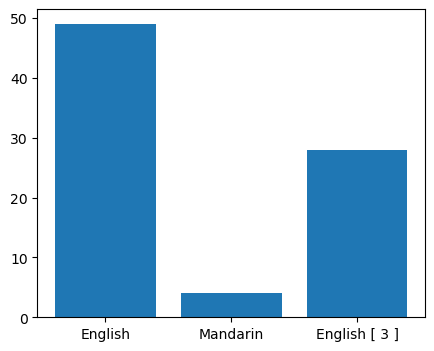

In [485]:
plt.figure(figsize=(5,4))
plt.bar(df['language'], df['index'])
plt.show()

In [497]:
def clean_lang(lang):
    if not lang:
        return None
    
    # removing [] brackets
    lang = re.sub(r"\[.*?\]", "", lang)
    
    return lang.strip()

In [499]:
df["language"] = df["language"].apply(clean_lang)

In [501]:
df.groupby('language')['index'].count()

language
English     49
Mandarin     1
Name: index, dtype: int64

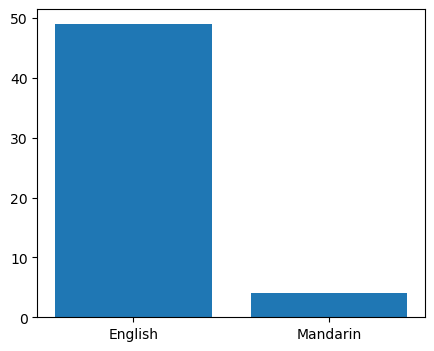

In [503]:
plt.figure(figsize=(5,4))
plt.bar(df['language'], df['index'])
plt.show()

### Running Time Column

In [505]:
def clean_time(runtime):
    return runtime.split()[0]

In [507]:
df['running_time'] = df['running_time'].apply(clean_time)

### Director Column

In [516]:
# According to db requirements, changing type from object
df["director"] = df["director"].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)

In [530]:
# typecasting from object datatype to appropriate
df['title'] = df['title'].astype("string")
df['link'] = df['link'].astype('string')
df['language'] = df['language'].astype('string')
df['gross'] = df['gross'].astype('int64')
df['running_time'] = df['running_time'].astype('int')

### Leaving only needed columns and renaming them appropriately for loading in the datatabase

In [532]:
df_db = df[["title", "year", "director", "gross", "country", "language", "running_time", "genres"]].copy()

In [534]:
df_db = df_db.rename(columns={
    "year": "release_year",
    "gross": "box_office",
    "running_time": "duration_minutes",
    "genres": "genre"
})

In [538]:
df_db.head()

,title,release_year,director,box_office,country,language,duration_minutes,genre
0,Avatar,2009,James Cameron,2923710708,"United States, United Kingdom",English,162,"sci-fi, epic"
1,Avengers: Endgame,2019,"Anthony Russo, Joe Russo",2797501328,United States,English,181,superhero
2,Avatar: The Way of Water,2022,James Cameron,2334484620,United States,English,192,"sci-fi, epic"
3,Titanic,1997,James Cameron,2257906828,United States,English,195,"romance, epic, historical"
4,Ne Zha 2,2025,Jiaozi,2215690000,China,Mandarin,144,"adventure, fantasy, animated"


In [540]:
df_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             50 non-null     string
 1   release_year      50 non-null     int64 
 2   director          50 non-null     object
 3   box_office        50 non-null     int64 
 4   country           50 non-null     object
 5   language          50 non-null     string
 6   duration_minutes  50 non-null     int32 
 7   genre             50 non-null     object
dtypes: int32(1), int64(2), object(3), string(2)
memory usage: 3.1+ KB


## Saving the dataset as JSON file for Web Page Implementation

In [543]:
df_db.to_json("movies.json", orient="records", indent=2)